In [128]:
import scipy as sp
import numpy as np
import sys, os
import matplotlib.pyplot as plt
from scipy.constants import lambda2nu, nu2lambda, c
import importlib.util
from scipy.interpolate import CubicSpline
lumerical_path = r"C:\Program Files\Lumerical\v261\api\python"

# 2. Adicione esse caminho ao sys.path para que o Python encontre os pacotes internos
if lumerical_path not in sys.path:
    sys.path.append(lumerical_path)

# 3. Carregue o lumapi (usando o método que você já validou)
lumapiFile = os.path.join(lumerical_path, "lumapi.py")
spec = importlib.util.spec_from_file_location("lumapi", lumapiFile)
lumapi = importlib.util.module_from_spec(spec)
sys.modules["lumapi"] = lumapi
spec.loader.exec_module(lumapi)

# 4. AGORA IMPORTANTE: O lumopt precisa que o 'lumapi' esteja globalmente acessível
# nas variáveis do sistema para as dependências internas dele funcionarem.
import builtins
builtins.lumapi = lumapi 

# 5. Importe o lumopt normalmente (ele será encontrado porque adicionamos o caminho no passo 2)
import lumopt
from lumopt.utilities.wavelengths import Wavelengths
from lumopt.geometries.polygon import FunctionDefinedPolygon
from lumopt.utilities.materials import Material
from lumopt.figures_of_merit.modematch import ModeMatch
from lumopt.optimizers.generic_optimizers import ScipyOptimizers
from lumopt.optimization import Optimization

In [129]:
from IPython.core.display import HTML
from IPython.display import display, Math
from IPython.core.pylabtools import figsize

HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

figsize(8, 4)

In [130]:
fdtdApi = lumapi.FDTD(hide=False)

#units

um = 1e-6
nm = 1e-9

In [131]:
L = 2*um
L2 = 2.4*um
dL = L/12
L_rects = 10*dL
H = 220*nm

material = 'Si (Silicon) - Palik'
sub_material = 'SiO2 (Glass) - Palik'

x_original = np.arange(-L/2, L/2 + dL, dL)
initial_points_y_1 = np.array([0.5,1.2,2*0.69,2*0.75,2*0.78,2*0.74,2*0.85,2*0.72,2*0.87,2*0.72,2*0.83,2*0.7])*um/2
initial_points_y_2 = np.array([0.5,0.84,1.49,1.58,1.69,1.74,1.68,1.75,1.49,1.86,2.03,1.4])*um/2

gds_file_1 = "C:/Users/LucasGabriel/OneDrive/Documentos/Layouts_and_simulations/Lumerical/Laboratories/90° optical hybrid/Compact_Y_Branch.gds"

In [132]:
def y_branch_init_(fdtd): 

    #clear

    fdtd.switchtolayout()
    fdtd.selectall()
    fdtd.delete()

    #SIM parameters

    fdtd.addfdtd()
    fdtd.set('x', 0)
    fdtd.set('y', 0)
    fdtd.set('z', 0)
    fdtd.set('x span', L + 1.5*L_rects)
    fdtd.set('y span', 3*um)
    fdtd.set('z span', 3*H)
    fdtd.set('simulation time', 20*(L+1.5*L_rects)/c)
    fdtd.set('global source wavelength start', 1500*nm)
    fdtd.set('global source wavelength stop', 1600*nm)
    fdtd.set('z min bc','Symmetric')
    fdtd.set('background material', sub_material)
    fdtd.set('mesh accuracy', 4)

    # guides position

    fdtd.addrect()
    fdtd.set('name', 'poly_0')
    fdtd.set('material', material)
    fdtd.set('z', 0)
    fdtd.set('z span', H)
    fdtd.set('x', -L/2 + dL/2)
    fdtd.set('x span', dL)
    fdtd.set('y', 0)
    fdtd.set('y span', 0.5*um)
    fdtd.addtogroup('group')

    #fdtd.addrect()
    #fdtd.set('name', 'rect')
    #fdtd.set('material', material)
    #fdtd.set('z', 0)
    #fdtd.set('z span', H)
    #fdtd.set('x', L/2 + dL/2)
    #fdtd.set('x span', dL)
    #fdtd.set('y', 0)
    #fdtd.set('y span', 1.4*um)
    #fdtd.addtogroup('group')

    fdtd.addrect()
    fdtd.set('name', 'rect_0')
    fdtd.set('x', -(L+dL)/2)
    fdtd.set('x span', dL)
    fdtd.set('y', 0)
    fdtd.set('y span', 0.5*um)
    fdtd.set('z', 0)
    fdtd.set('z span', H)
    fdtd.set('material', material)
    fdtd.addtogroup('group')

    fdtd.addrect()
    fdtd.set('name', 'rect_1')
    fdtd.set('x', -L/2 - dL - L_rects/2)
    fdtd.set('x span', L_rects)
    fdtd.set('y', 0)
    fdtd.set('y span', 0.5*um)
    fdtd.set('z', 0)
    fdtd.set('z span', H)
    fdtd.set('material', material)
    fdtd.addtogroup('group')

    fdtd.addrect()
    fdtd.set('name', 'rect_2')
    fdtd.set('x', L/2+ dL + L_rects/2)
    fdtd.set('x span', L_rects)
    fdtd.set('y', 0.45*um)
    fdtd.set('y span', 0.5*um)
    fdtd.set('z', 0)
    fdtd.set('z span', H)
    fdtd.set('material', material)
    fdtd.addtogroup('group')

    fdtd.addrect()
    fdtd.set('name', 'rect_3')
    fdtd.set('x', L/2+ dL + L_rects/2)
    fdtd.set('x span', L_rects)
    fdtd.set('y', -0.45*um)
    fdtd.set('y span', 0.5*um)
    fdtd.set('z', 0)
    fdtd.set('z span', H)
    fdtd.set('material', material)
    fdtd.addtogroup('group')

    ## SOURCE
    fdtd.addmode()
    fdtd.set('direction','Forward')
    fdtd.set('injection axis','x-axis')
    #fdtd.set('polarization angle',0)
    fdtd.set('y',0);
    fdtd.set("y span",3*um)
    fdtd.set('x',-2*um)
    fdtd.set('center wavelength',1550*nm)
    fdtd.set('wavelength span',0)
    fdtd.set('mode selection','fundamental TE mode')

    ## MESH IN OPTIMIZABLE REGION
    fdtd.addmesh()
    fdtd.set('x min', -L/2 + dL)
    fdtd.set('x max', L/2 + dL)
    fdtd.set('y',0)
    fdtd.set('y span',3*um)
    fdtd.set('z',0)
    fdtd.set('z span',3*H)
    fdtd.set('dx',20*nm)
    fdtd.set('dy',20*nm)
    fdtd.set('dz',20*nm)

    ## OPTIMIZATION FIELDS MONITOR IN OPTIMIZABLE REGION
    
    fdtd.addpower()
    fdtd.set('name','opt_fields')
    fdtd.set('monitor type','3D')
    fdtd.set('x',0)
    fdtd.set('x span',(5/6)*5*um)
    fdtd.set('y',0)
    fdtd.set('y span',(5/6)*3*um)
    fdtd.set('z',0)
    fdtd.set('z span',0.4e-6)
    
    ## FOM FIELDS
    
    fdtd.addpower()
    fdtd.set('name','fom')
    fdtd.set('monitor type','2D X-Normal')
    fdtd.set('x',2*um + 3.28947368e-09 + 1.12032799e-08)
    fdtd.set('y',0)
    fdtd.set('y span',3*um)
    fdtd.set('z',0)
    fdtd.set('z span',3*H)

In [133]:
def y_branch_init_2(fdtd):
    #clear

    fdtd.switchtolayout()
    fdtd.selectall()
    fdtd.delete()

    #SIM parameters

    fdtd.addfdtd()
    fdtd.set('x', 0)
    fdtd.set('y', 0)
    fdtd.set('z', 0)
    fdtd.set('x span', L + 1.5*L_rects)
    fdtd.set('y span', 3*um)
    fdtd.set('z span', 3*H)
    fdtd.set('simulation time', 20*(L+1.5*L_rects)/c)
    fdtd.set('global source wavelength start', 1500*nm)
    fdtd.set('global source wavelength stop', 1600*nm)
    fdtd.set('z min bc','Symmetric')
    fdtd.set('background material', sub_material)
    fdtd.set('mesh accuracy', 4)

    ## SOURCE
    fdtd.addmode()
    fdtd.set('direction','Forward')
    fdtd.set('injection axis','x-axis')
    #fdtd.set('polarization angle',0)
    fdtd.set('y',0);
    fdtd.set("y span",3*um)
    fdtd.set('x',-2*um)
    fdtd.set('center wavelength',1550*nm)
    fdtd.set('wavelength span',0)
    fdtd.set('mode selection','fundamental TE mode')

    ## MESH IN OPTIMIZABLE REGION
    fdtd.addmesh()
    fdtd.set('x min', -L2/2)
    fdtd.set('x max', L2/2 + L2/12)
    fdtd.set('y',0)
    fdtd.set('y span',3*um)
    fdtd.set('z',0)
    fdtd.set('z span',3*H)
    fdtd.set('dx',20*nm)
    fdtd.set('dy',20*nm)
    fdtd.set('dz',20*nm)

    ## OPTIMIZATION FIELDS MONITOR IN OPTIMIZABLE REGION
    
    fdtd.addpower()
    fdtd.set('name','opt_fields')
    fdtd.set('monitor type','3D')
    fdtd.set('x',0)
    fdtd.set('x span',(5/6)*5*um)
    fdtd.set('y',0)
    fdtd.set('y span',(5/6)*3*um)
    fdtd.set('z',0)
    fdtd.set('z span',0.4e-6)
    
    ## FOM FIELDS
    
    fdtd.addpower()
    fdtd.set('name','fom')
    fdtd.set('monitor type','2D X-Normal')
    fdtd.set('x',2*um + 3.28947368e-09 + 1.12032799e-08 - 3.12911722e-09 + 2.52525253e-09)
    fdtd.set('y',0)
    fdtd.set('y span',3*um)
    fdtd.set('z',0)
    fdtd.set('z span',3*H)

    
    ## building the device:

    fdtd.addrect()
    fdtd.set('name', 'poly_0')
    fdtd.set('material', material)
    fdtd.set('z', 0)
    fdtd.set('z span', H)
    fdtd.set('x', -L2/2 - L2/24)
    fdtd.set('x span', L2/12)
    fdtd.set('y', 0)
    fdtd.set('y span', 0.5*um)
    fdtd.addtogroup('group')

    #fdtd.addrect()
    #fdtd.set('name', 'rect')
    #fdtd.set('material', material)
    #fdtd.set('z', 0)
    #fdtd.set('z span', H)
    #fdtd.set('x', L2/2 + L2/24)
    #fdtd.set('x span', L2/12)
    #fdtd.set('y', 0)
    #fdtd.set('y span', 1.4*um)
    #fdtd.addtogroup('group')

    fdtd.addrect()
    fdtd.set('name', 'rect_1')
    fdtd.set('x', -L2/2 - L2/12 - 5*L2/24)
    fdtd.set('x span', 5*L2/12)
    fdtd.set('y', 0)
    fdtd.set('y span', 0.5*um)
    fdtd.set('z', 0)
    fdtd.set('z span', H)
    fdtd.set('material', material)
    fdtd.addtogroup('group')

    fdtd.addrect()
    fdtd.set('name', 'rect_2')
    fdtd.set('x', L2/2 + L2/12 + 5*L2/24)
    fdtd.set('x span', 5*L2/12)
    fdtd.set('y', 0.45*um)
    fdtd.set('y span', 0.5*um)
    fdtd.set('z', 0)
    fdtd.set('z span', H)
    fdtd.set('material', material)
    fdtd.addtogroup('group')

    fdtd.addrect()
    fdtd.set('name', 'rect_3')
    fdtd.set('x', L2/2 + L2/12 + 5*L2/24)
    fdtd.set('x span', 5*L2/12)
    fdtd.set('y', -0.45*um)
    fdtd.set('y span', 0.5*um)
    fdtd.set('z', 0)
    fdtd.set('z span', H)
    fdtd.set('material', material)
    fdtd.addtogroup('group')

In [134]:
#y_branch_init_(fdtdApi)

In [ ]:
L_opt = L2
initial_points_x = np.linspace(-L_opt/2, L_opt/2+L_opt/12, 12)
initial_points_y = initial_points_y_2

def splitter(params):
    ''' Defines a taper where the paramaters are the y coordinates of the nodes of a cubic spline. '''

    ## Include two set points based on the initial guess. The should attach the optimizeable geometry to the input and output 
    points_x = np.concatenate(([initial_points_x.min() - 0.01e-6], initial_points_x, [initial_points_x.max() + 0.01e-6]))
    points_y = np.concatenate(([0.25*um], params, [0.7*um]))

    ## Up sample the polygon points for a smoother curve. Some care should be taken with interp1d object. Higher degree fit
    # "cubic", and "quadratic" can vary outside of the footprint of the optimization. The parameters are bounded, but the
    # interpolation points are not. This can be particularly problematic around the set points.
    n_interpolation_points = 100
    polygon_points_x = np.linspace(min(points_x), max(points_x), n_interpolation_points)
    interpolator = sp.interpolate.interp1d(points_x, points_y, kind = 'cubic')
    polygon_points_y = interpolator(polygon_points_x)

    ### Zip coordinates into a list of tuples, reflect and reorder. Need to be passed ordered in a CCW sense 
    polygon_points_up = [(x, y) for x, y in zip(polygon_points_x, polygon_points_y)]
    polygon_points_down = [(x, -y) for x, y in zip(polygon_points_x, polygon_points_y)]
    polygon_points = np.array(polygon_points_up[::-1] + polygon_points_down)
    return polygon_points

Accurate interface detection enabled
Wavelength range of source object will be superseded by the global settings.


C:\Program Files\Lumerical\v261\api\python\lumopt\utilities\plotter.py:64: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  self.fig.show()


Running scipy optimizer
bounds = [[0.2 0.8]
 [0.2 0.8]
 [0.2 0.8]
 [0.2 0.8]
 [0.2 0.8]
 [0.2 0.8]
 [0.2 0.8]
 [0.2 0.8]
 [0.2 0.8]
 [0.2 0.8]
 [0.2 0.8]
 [0.2 0.8]]
start = [0.25  0.42  0.745 0.79  0.845 0.87  0.84  0.875 0.745 0.93  1.015 0.7  ]
Making forward solve
Making adjoint solve
Running solves
Processing forward solve
FOM = 0.8292809640283753
Processing adjoint solve in sequence
Getting d eps: dx = 1e-09
............Saved frame
Making forward solve
Making adjoint solve
Running solves
Processing forward solve
FOM = 0.6897192615402805
Processing adjoint solve in sequence
Getting d eps: dx = 1e-09
............Making forward solve
Making adjoint solve
Running solves
Processing forward solve
FOM = 0.8424841197104279
Processing adjoint solve in sequence
Getting d eps: dx = 1e-09
............Saved frame
Making forward solve
Making adjoint solve
Running solves
Processing forward solve
FOM = 0.8622522373809508
Processing adjoint solve in sequence
Getting d eps: dx = 1e-09
............

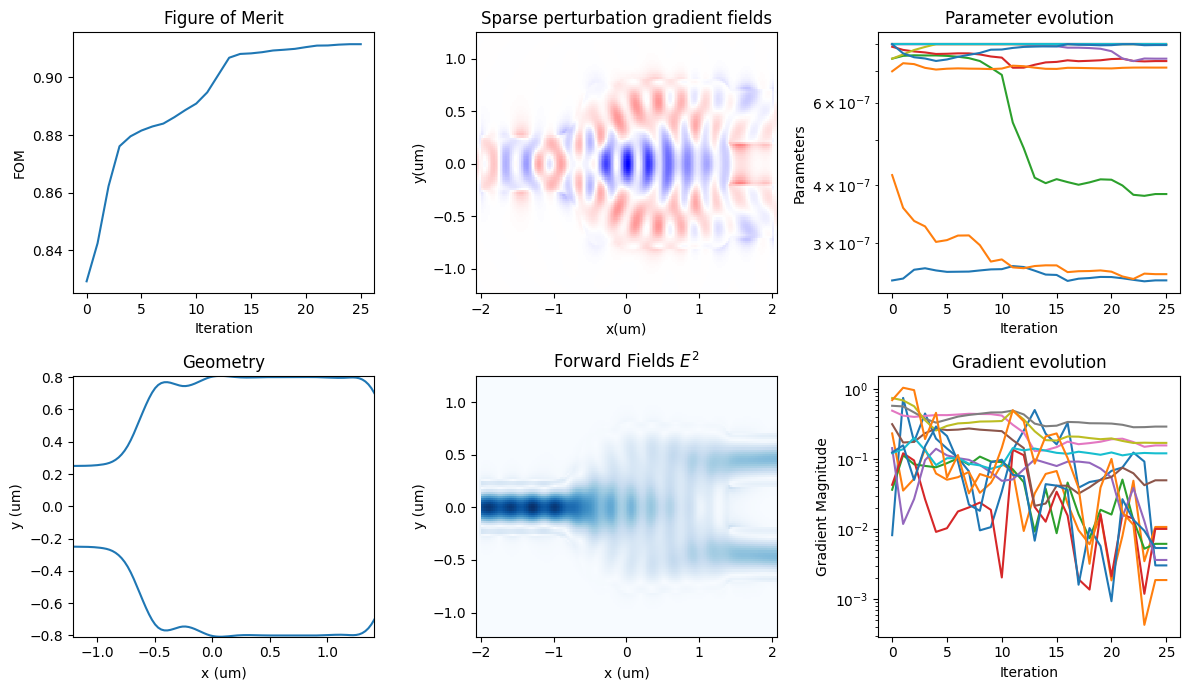

In [136]:
wavelengths = Wavelengths(start = 1500e-9, stop = 1600e-9, points = 11)

prev_results = initial_points_y

# L-BFGS methods allows the parameters to be bound. These should enforse the optimization footprint defined in the setup
bounds = [(0.2e-6, 0.8e-6)] * initial_points_y.size


# Set device and cladding materials, as well as as device layer thickness
eps_in = Material(name = 'Si (Silicon) - Palik', mesh_order = 2)
eps_out = Material(name = 'SiO2 (Glass) - Palik', mesh_order = 3)
depth = 220.0e-9

# Initialize FunctionDefinedPolygon class
polygon = FunctionDefinedPolygon(func = splitter, 
                                 initial_params = prev_results,
                                 bounds = bounds,
                                 z = 0.0,
                                 depth = depth,
                                 eps_out = eps_out, eps_in = eps_in,
                                 edge_precision = 5,
                                 dx = 1.0e-9)

######## FIGURE OF MERIT ########
fom = ModeMatch(monitor_name = 'fom', 
                mode_number = 'fundamental TE mode',
                direction = 'Forward',
                target_T_fwd = lambda wl: np.ones(wl.size),
                norm_p = 1)

######## OPTIMIZATION ALGORITHM ########
scaling_factor = 1.0e6
optimizer = ScipyOptimizers(max_iter = 200,
                            method = 'L-BFGS-B',
                            scaling_factor = scaling_factor,
                            pgtol = 1.0e-5,
                            ftol = 1.0e-5,
                            scale_initial_gradient_to = 0.0)

######## PUT EVERYTHING TOGETHER ########
opt = Optimization(base_script = y_branch_init_2,
                   wavelengths = wavelengths,
                   fom = fom,
                   geometry = polygon,
                   optimizer = optimizer,
                   use_var_fdtd = False,
                   hide_fdtd_cad = False,
                   use_deps = True,
                   plot_history = True,
                   store_all_simulations = False)

######## RUN THE OPTIMIZER ########
results = opt.run()